In [1]:
from pathlib import Path

video_data_path = Path("../data/video/UCF101_Selected")

print("Dataset exists:", video_data_path.exists())
print("Activity folders:", [folder.name for folder in video_data_path.iterdir()])

Dataset exists: True
Activity folders: ['BodyWeightSquats', 'WalkingWithDog']


In [2]:
for activity_folder in video_data_path.iterdir():
    if activity_folder.is_dir():
        video_files = list(activity_folder.glob("*.avi"))
        print(activity_folder.name, ":", len(video_files), "videos")

BodyWeightSquats : 112 videos
WalkingWithDog : 123 videos


In [4]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [5]:
sample_video = list(
    (video_data_path / "WalkingWithDog").glob("*.avi")
)[0]

cap = cv2.VideoCapture(str(sample_video))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

cap.release()

print("Sample video:", sample_video.name)
print("Frame count:", frame_count)
print("Frames per second:", fps)

Sample video: v_WalkingWithDog_g01_c01.avi
Frame count: 240
Frames per second: 29.97002997002997


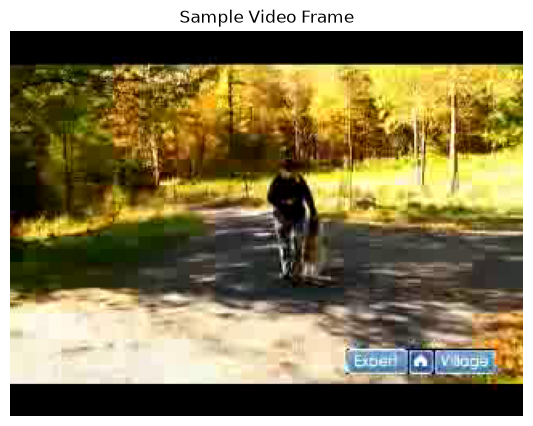

In [6]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(sample_video))

success, frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title("Sample Video Frame")
    plt.show()
else:
    print("Could not read the video frame.")

In [7]:
import cv2
import numpy as np

def extract_video_frames(video_path, frame_count=10):
    cap = cv2.VideoCapture(str(video_path))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        frame_count,
        dtype=int
    )

    frames = []

    for index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(index))
        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (128, 128))
            frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return None

    return np.array(frames)

In [8]:
sample_frames = extract_video_frames(sample_video, frame_count=10)

print("Extracted frames shape:", sample_frames.shape)

Extracted frames shape: (10, 128, 128, 3)


In [9]:
import pandas as pd

video_records = []

activity_labels = {
    "BodyWeightSquats": 0,
    "WalkingWithDog": 1
}

for activity_name, label in activity_labels.items():
    activity_folder = video_data_path / activity_name

    for video_file in activity_folder.glob("*.avi"):
        video_records.append({
            "file_path": str(video_file),
            "activity": activity_name,
            "label": label
        })

video_df = pd.DataFrame(video_records)

print("Total videos:", len(video_df))
print("\nVideos per activity:")
print(video_df["activity"].value_counts())
print("\nFirst five records:")
display(video_df.head())

Total videos: 235

Videos per activity:
activity
WalkingWithDog      123
BodyWeightSquats    112
Name: count, dtype: int64

First five records:


,file_path,activity,label
0,..\data\video\UCF101_Selected\BodyWeightSquats...,BodyWeightSquats,0
1,..\data\video\UCF101_Selected\BodyWeightSquats...,BodyWeightSquats,0
2,..\data\video\UCF101_Selected\BodyWeightSquats...,BodyWeightSquats,0
3,..\data\video\UCF101_Selected\BodyWeightSquats...,BodyWeightSquats,0
4,..\data\video\UCF101_Selected\BodyWeightSquats...,BodyWeightSquats,0


In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    video_df,
    test_size=0.2,
    random_state=42,
    stratify=video_df["label"]
)

print("Training videos:", len(train_df))
print("Testing videos:", len(test_df))

print("\nTraining distribution:")
print(train_df["activity"].value_counts())

print("\nTesting distribution:")
print(test_df["activity"].value_counts())

Training videos: 188
Testing videos: 47

Training distribution:
activity
WalkingWithDog      98
BodyWeightSquats    90
Name: count, dtype: int64

Testing distribution:
activity
WalkingWithDog      25
BodyWeightSquats    22
Name: count, dtype: int64


In [11]:
def prepare_video_data(dataframe):
    video_frames = []
    video_labels = []

    for _, row in dataframe.iterrows():
        frames = extract_video_frames(
            row["file_path"],
            frame_count=10
        )

        if frames is not None and len(frames) == 10:
            video_frames.append(frames)
            video_labels.append(row["label"])

    return np.array(video_frames), np.array(video_labels)

In [12]:
X_train_video, y_train_video = prepare_video_data(train_df)

X_test_video, y_test_video = prepare_video_data(test_df)

print("Training data shape:", X_train_video.shape)
print("Training labels shape:", y_train_video.shape)

print("Testing data shape:", X_test_video.shape)
print("Testing labels shape:", y_test_video.shape)

Training data shape: (182, 10, 128, 128, 3)
Training labels shape: (182,)
Testing data shape: (47, 10, 128, 128, 3)
Testing labels shape: (47,)


In [13]:
X_train_video = X_train_video.astype("float32") / 255.0
X_test_video = X_test_video.astype("float32") / 255.0

print("Training pixel range:", X_train_video.min(), "to", X_train_video.max())
print("Testing pixel range:", X_test_video.min(), "to", X_test_video.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    TimeDistributed,
    Conv2D,
    MaxPooling2D,
    Flatten,
    LSTM,
    Dense,
    Dropout
)

video_model = Sequential([
    Input(shape=(10, 128, 128, 3)),

    TimeDistributed(Conv2D(16, (3, 3), activation="relu")),
    TimeDistributed(MaxPooling2D((2, 2))),

    TimeDistributed(Conv2D(32, (3, 3), activation="relu")),
    TimeDistributed(MaxPooling2D((2, 2))),

    TimeDistributed(Flatten()),

    LSTM(64),

    Dense(32, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

video_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 126, 126,   │           448 │
│ (TimeDistributed)               │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 63, 63, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 61, 61, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 30, 30, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 28800)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     7,389,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,396,641 (28.22 MB)

 Trainable params: 7,396,641 (28.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
video_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Video model compiled successfully.")

Video model compiled successfully.


In [16]:
history_video = video_model.fit(
    X_train_video,
    y_train_video,
    validation_split=0.2,
    epochs=10,
    batch_size=4,
    shuffle=True
)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 0.5034 - loss: 0.7455 - val_accuracy: 0.7297 - val_loss: 0.6465
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.5724 - loss: 0.6350 - val_accuracy: 0.7838 - val_loss: 0.6262
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.7724 - loss: 0.5090 - val_accuracy: 0.8108 - val_loss: 0.4927
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 291ms/step - accuracy: 0.8276 - loss: 0.4247 - val_accuracy: 0.7297 - val_loss: 0.5476
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 296ms/step - accuracy: 0.7862 - loss: 0.4252 - val_accuracy: 0.8108 - val_loss: 0.4191
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - accuracy: 0.8759 - loss: 0.2854 - val_accuracy: 0.8919 - val_loss: 0.2986
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - accuracy: 0.9517 - loss: 0.2126 - val_accuracy: 0.9459 - val_loss: 0.2563
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 304ms/step - accuracy: 0.9724 - loss: 0.1704 - val_accu

In [17]:
test_loss, test_accuracy = video_model.evaluate(
    X_test_video,
    y_test_video,
    batch_size=4
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8936 - loss: 0.2249
Test loss: 0.22486676275730133
Test accuracy: 0.8936170339584351


In [18]:
video_model.save("../models/video_activity_model.keras")

print("Video model saved successfully.")

Video model saved successfully.


In [19]:
from tensorflow.keras.models import load_model

saved_video_model = load_model("../models/video_activity_model.keras")

print("Saved video model loaded successfully.")

Saved video model loaded successfully.
